# EMNIST Handwritten Letter Classification


This project builds a neural network to recognize handwritten English letters using the **EMNIST Letters dataset**.

Unlike the MNIST dataset, which contains 10 digit classes (`0–9`), EMNIST Letters contains 26 classes representing the letters `A–Z`. Differences in handwriting styles make this a more challenging image-classification problem.


In [70]:
# Import
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import os
import torchvision.datasets as datasets
import torchvision.transforms as transforms


Check to see if the `DEVICE` available is "cuda" or "cpu"

In [71]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Available device: {device} ")

Available device: cuda 


## 1. EMNIST Letter Images

The **EMNIST Letters dataset** is an extension of MNIST containing handwritten English letters instead of digits.

The dataset contains:

- **124,800 training images**
- **20,800 test images**
- **26 letter classes** representing `A–Z`
- Grayscale images with a size of **28 × 28 pixels**

## 1.1 Loading the Dataset

The dataset can be loaded using `torchvision.datasets.EMNIST`.

The argument `split="letters"` selects only the handwritten-letter portion of EMNIST. The dataset can be downloaded automatically by setting `download=True`.

In [72]:
data_path='./EMNIST_data'

# Check if path exist and that is a folder not a file
if os.path.exists(data_path) and os.path.isdir(data_path):
    download=False
    print("EMNIST data folder present.Loading locally ")
else:
    download=True
    print("EMNIST data folder not present. Dowloading data")

# Download EMNIST training and test set

train_dataset=datasets.EMNIST(
    root=data_path,download=download,train=True,
    split='letters' # to get only letter from dataset
)

test_dataset=datasets.EMNIST(
    root=data_path,download=download,train=False,split='letters'
)

EMNIST data folder present.Loading locally 


## 1.2 Exploring the Raw Data

Before preprocessing the dataset, it is helpful to visualize some raw images.

Examining different samples helps us understand:

- How handwriting varies between people
- Whether some letters look similar to each other
- Whether the images have the correct orientation
- What preprocessing may be required before training

The raw EMNIST images may appear rotated or flipped because of how the dataset was originally stored. This must be corrected before using the images for training.

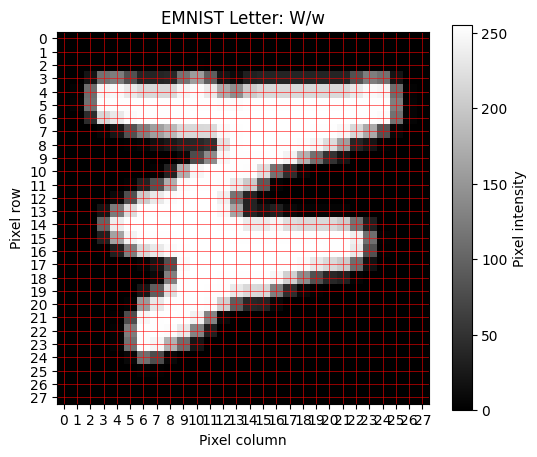

Image type: <class 'PIL.Image.Image'>
Numeric label: 23
Letter: W


In [73]:
import matplotlib.pyplot as plt
import numpy as np

index = 0  # Change this number to view another image

# Get the image and label
img, label = train_dataset[index]

# Convert the numeric label to a letter
letter = chr(ord("A") + label - 1)

# Display the image
plt.figure(figsize=(6, 5))
plt.imshow(np.array(img), cmap="gray", vmin=0, vmax=255)

plt.title(f"EMNIST Letter: {letter}/{letter.lower()}")
plt.xlabel("Pixel column")
plt.ylabel("Pixel row")

plt.xticks(range(28))
plt.yticks(range(28))
plt.grid(color="red", linewidth=0.4)

plt.colorbar(label="Pixel intensity")
plt.show()

print(f"Image type: {type(img)}")
print(f"Numeric label: {label}")
print(f"Letter: {letter}")

Raw EMNIST letters may appear rotated or flipped because of the way the images are stored. A model can still learn from them because all images follow the same orientation. Orientation correction is mainly useful for human visualization.

## 1.3 Image Preprocessing

Before training, each image is processed using PyTorch transforms:

- `ToTensor()` converts the PIL image into a PyTorch tensor and scales its pixel values from `0–255` to `0–1`.
- `Normalize(mean, std)` standardizes the pixel values using the dataset's mean and standard deviation.
- `Compose()` combines multiple transformations and applies them in sequence.

Normalization can help the model train faster and more reliably by keeping the input values on a consistent scale.

The transformations are applied automatically whenever an image is retrieved from the dataset. The original image files are not modified.

In [74]:
# mean, std for EMNIST letter dataset
mean = (0.1736,)
std = (0.3317,)


# convert image to tensor and then normalize
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean,std=std) 
]
)

# assign transformation to test and train set
train_dataset.transform=transform
test_dataset.transform=transform

### Assigning Transforms to a Dataset

The dataset's `.transform` attribute stores the preprocessing operations that should be applied to each image.By assigning my previously defined `transform` pipeline to this attribute, every image is automatically converted to a tensor and normalized when it is loaded.

Now take another look at the same sample. 
This time, you’re seeing the raw tensor after the transformations were applied.

In [75]:
index=500 
image_tensor,label=train_dataset[index]
print(image_tensor)
print(f"Label is {label} ")

tensor([[[-0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234,
          -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234,
          -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234,
          -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234],
         [-0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234,
          -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234,
          -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234,
          -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234],
         [-0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234,
          -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234,
          -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234,
          -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234],
         [-0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.4997,
          -0.4761, -0.4761, -0.4761, -0.4997, -0

First, each pixel value (originally between 0 and 255) was scaled to a range between 0 and 1. Then, those values were normalized by subtracting the dataset’s average pixel value and dividing by its standard deviation.

That’s why the numbers you see now are centered around 0—some are negative, some positive. These values show how much brighter or darker each pixel is compared to the dataset average. This normalization step helps  model train faster and more reliably.


## Visualizing a Transformed Image

EMNIST images are stored in a rotated or flipped orientation. The `correct_image_orientation()` function temporarily rotates and flips an image so that it can be viewed normally.

This correction is used only when displaying an image:

- It makes the handwritten letter easier for us to recognize.
- It does not modify the dataset.
- It is not part of the model's preprocessing pipeline.
- The model continues to train on the original image orientation.

Since all dataset images have a consistent orientation, the model can still learn their patterns correctly.

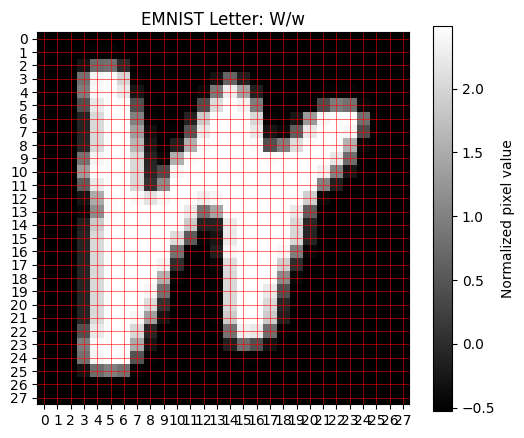

In [76]:
import matplotlib.pyplot as plt
from torchvision.transforms import functional as F

def correct_image_orientation(image):
    rotated = F.rotate(image, 90)
    flipped = F.vflip(rotated)
    return flipped

# Get a transformed image from the dataset
index = 0
img_tensor, label = train_dataset[index]

# Correct orientation only for visualization
img_corrected = correct_image_orientation(img_tensor)

# Convert label number to letter
letter = chr(ord("A") + label - 1)

# Display the image
plt.figure(figsize=(6, 5))
plt.imshow(img_corrected.squeeze(), cmap="gray")

plt.title(f"EMNIST Letter: {letter}/{letter.lower()}")
plt.xticks(range(28))
plt.yticks(range(28))
plt.grid(color="red", linewidth=0.4)
plt.colorbar(label="Normalized pixel value")

plt.show()

## 1.4 Loading Data in Batches

A PyTorch `DataLoader` divides a dataset into smaller groups called **batches**.

Instead of processing all images at once, the model processes one batch at a time. This:

- Reduces memory usage
- Makes training more efficient
- Provides frequent model updates during each epoch

Two DataLoaders are created:

- **Training DataLoader:** Batches and shuffles the training data.
- **Test DataLoader:** Batches the test data without shuffling.

Shuffling the training data changes the sample order during each epoch, helping the model learn without depending on the dataset's original order.

In [77]:
def create_emnist_dataloader(train_dataset,test_dataset,batch_size=64):
    # Create training dataset dataloader
    train_dataloader=DataLoader(
        dataset=train_dataset,
        shuffle=True,
        batch_size=batch_size,
    )

    # Create test dataset dataloader
    test_dataloader=DataLoader(
        dataset=test_dataset,shuffle=False,batch_size=batch_size
    )


    # return dataloaders
    return train_dataloader,test_dataloader


Examine the contents of the resulting `DataLoader` objects. 
This will help you verify that the artifacts have been correctly organized into batches and that the shuffling has been applied to the training data.

## 2. Building the Neural Network

Now that the data has been prepared and organized into batches, the next step is to create a neural network for letter classification.

The model will receive a `28 × 28` grayscale image and predict one of the 26 letter classes from `A` to `Z`.

This section includes:

- Defining the neural network architecture
- Choosing a loss function to measure prediction error
- Selecting an optimizer to update the model's parameters

During training, the loss function measures how far the predictions are from the correct labels. The optimizer then uses the calculated gradients to improve the model's weights and biases.

In [85]:
def initialize_emnist_model(num_classes=26):
    # set seed for reproducibility
    torch.manual_seed(42)
    # define model
    model=nn.Sequential(
        nn.Flatten(),
        nn.Linear(784,256),nn.ReLU(),
        nn.Linear(256,128),nn.ReLU(),
        nn.Linear(128,num_classes)
    )
    # define loss function
    loss_function=nn.CrossEntropyLoss()
    
    # define optimizer
    optimizer=optim.Adam(model.parameters(),lr=0.001)

    # return model, loss and optimizer
    return model,loss_function,optimizer

## 3. Training and Evaluating the Model

### 3.1 Training for One Epoch

One **epoch** means the model processes the entire training dataset once.

For every batch, the training loop performs these steps:

1. Clear gradients left from the previous batch.
2. Pass the input images through the model.
3. Calculate the loss by comparing predictions with correct labels.
4. Calculate gradients using backpropagation.
5. Update the model's parameters using the optimizer.
6. Count correct predictions to measure accuracy.

After processing all batches:

- **Average loss** shows the model's average prediction error.
- **Accuracy** shows the percentage of images classified correctly.

Lower loss and higher accuracy generally indicate that the model is learning.

In [86]:
def train_epoch(model,loss_function,optimizer,train_dataloader,device):
    # move model to device
    model.to(device)
    
    # set model to training mode
    model.train()
    
    # set initial values as 0
    running_loss=0
    num_correct_prediction=0
    # iterate each batchs in epoch
    for batch_id,(input,target) in enumerate(train_dataloader):
        # move input, target to gpu
        input,target=input.to(device),target.to(device)
        # make start value as 0 for target
        target-=1
        #Zero the gradient
        optimizer.zero_grad()
        # Make prediction
        output=model(input)
        # calculate loss
        loss=loss_function(output,target)
        # calculate gradient
        loss.backward()
        # update parameters
        optimizer.step()
        # convert loss tenstor to python number
        loss_value=loss.item()
        # accumulate running loss for each epoch
        running_loss+=loss_value
        # find predicted indices
        predicted_index=torch.argmax(output,dim=1)
        # find if target and model prediction same and count it
        correct_prediction=predicted_index.eq(target).sum().item()
        # add sum of correct prediction in each batch
        num_correct_prediction+=correct_prediction

    # find average loss
    average_loss=running_loss/len(train_dataloader)
    # find accuracy per epoch
    accuracy=100*(num_correct_prediction/len(train_dataloader.dataset))
    # print loss and accuracy after each epoch
    print(f"Epoch loss: {average_loss:.3f} | Accuracy: {accuracy:.3f} ")
    # return model, average loss
    return model,average_loss
        
        
    

# running one epoch to verify if it is working fine

In [87]:
train_dataloader,test_dataloader=create_emnist_dataloader(train_dataset,test_dataset)
model,loss_function,optimizer=initialize_emnist_model()
model_one_train_epoch=train_epoch(model,loss_function,optimizer,train_dataloader,device)

Epoch loss: 0.599 | Accuracy: 81.506 


## 3.2 Evaluating the Model

After training, the model is evaluated using the test dataset, which contains images that were not used to update the model.

Evaluation helps determine whether the model can generalize to new handwritten letters instead of only learning the training examples.

During evaluation:

1. Set the model to evaluation mode.
2. Disable gradient calculation because parameters are not updated.
3. Pass test images through the model.
4. Compare predicted classes with the correct labels.
5. Calculate the overall test accuracy.

A high test accuracy indicates that the model performs well on unseen handwritten letters.

In [88]:
def evaluate(model,test_dataloader,device):
    # set model to evaluation mode
    model.eval()
    # initialze value to 0
    total_correct_prediction=0
    # disable gradient calculation
    with torch.no_grad():
        # iterate over batches in test set
        for input,target in (test_dataloader):
            # move input and target to gpu
            input,target=input.to(device),target.to(device)
            # make target starting index as 0
            target-=1
            # make prediction
            output=model(input)
            # find predicted index
            prediction_index=torch.argmax(output,dim=1)
            # compare predicted index with target and count it
            correct_prediction=prediction_index.eq(target).sum().item()
            # Sum correct prediction for each batch
            total_correct_prediction+=correct_prediction
    # find accuracy for each batch
    accuracy=100*(total_correct_prediction/len(test_dataloader.dataset))
    # print accuracy
    print(f"Accuracy: {accuracy} ")
    # return accuracy percentage
    return accuracy
    